# Home Credit PD Scorecard Validation and Business Use

This notebook takes the scorecard outputs from the build notebook and turns them into a **portfolio-ready validation and business interpretation pack**.

## What this notebook does
- evaluates discrimination using **AUC, Gini and KS**
- reviews score distributions and risk bands
- builds **decile / rank-order tables**
- checks **calibration**
- proposes a simple **approval and review strategy**
- translates model outputs into business language for interviews and GitHub

This is the notebook that shows the scorecard is not just a model, but a usable credit decision tool.

## 1. Load saved scorecard artefacts

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

PROCESSED_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../outputs/tables/scorecard_outputs")

TARGET = "TARGET"
ID_COL = "SK_ID_CURR"

iv_summary = pd.read_csv(OUTPUT_DIR / "01_iv_summary.csv")
woe_table = pd.read_csv(OUTPUT_DIR / "02_woe_table.csv")
coef_table = pd.read_csv(OUTPUT_DIR / "03_scorecard_coefficients.csv")
scorecard_points = pd.read_csv(OUTPUT_DIR / "04_scorecard_points.csv")
train_scored = pd.read_csv(OUTPUT_DIR / "05_train_scored.csv")
test_scored = pd.read_csv(OUTPUT_DIR / "06_test_scored.csv")
scorecard_metadata = pd.read_csv(OUTPUT_DIR / "07_scorecard_metadata.csv")

scorecard_metadata

,metric,value
0,train_auc,0.706182
1,test_auc,0.706252
2,base_score,600.000000
3,base_odds,0.080000
4,pdo,20.000000
5,n_features,12.000000


## 2. Core validation metrics

AUC is useful, but it is not enough on its own.  
A bank-style validation summary usually also looks at **Gini** and **KS**.

In [2]:
def ks_statistic(y_true, pd_pred):
    df_ks = pd.DataFrame({"y_true": y_true, "pd_pred": pd_pred}).sort_values("pd_pred", ascending=False).reset_index(drop=True)
    df_ks["good"] = 1 - df_ks["y_true"]
    df_ks["bad"] = df_ks["y_true"]
    df_ks["cum_good"] = df_ks["good"].cumsum() / df_ks["good"].sum()
    df_ks["cum_bad"] = df_ks["bad"].cumsum() / df_ks["bad"].sum()
    df_ks["ks_gap"] = np.abs(df_ks["cum_bad"] - df_ks["cum_good"])
    return df_ks["ks_gap"].max(), df_ks

test_auc = roc_auc_score(test_scored[TARGET], test_scored["pd_pred"])
test_gini = 2 * test_auc - 1
test_ks, ks_table = ks_statistic(test_scored[TARGET], test_scored["pd_pred"])

validation_summary = pd.DataFrame({
    "metric": ["AUC", "Gini", "KS"],
    "value": [test_auc, test_gini, test_ks]
})

validation_summary

,metric,value
0,AUC,0.706252
1,Gini,0.412504
2,KS,0.302067


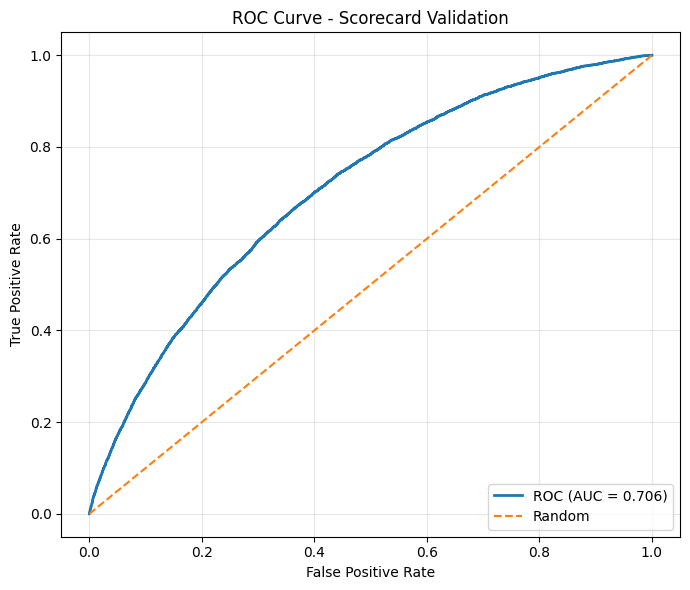

In [3]:
plt.figure(figsize=(7, 6))
fpr, tpr, _ = roc_curve(test_scored[TARGET], test_scored["pd_pred"])
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Scorecard Validation")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

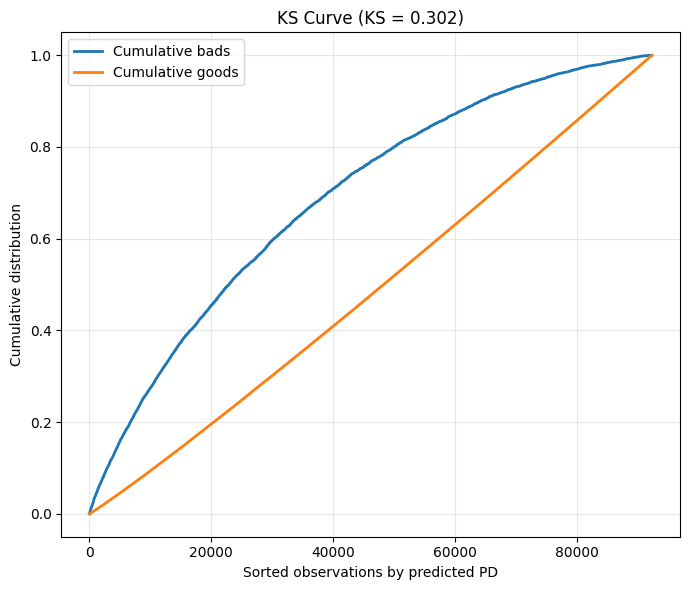

In [4]:
plt.figure(figsize=(7, 6))
plt.plot(ks_table["cum_bad"], label="Cumulative bads", linewidth=2)
plt.plot(ks_table["cum_good"], label="Cumulative goods", linewidth=2)
plt.title(f"KS Curve (KS = {test_ks:.3f})")
plt.xlabel("Sorted observations by predicted PD")
plt.ylabel("Cumulative distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Rank ordering by score decile

A good scorecard should show clear rank ordering:
- safer score buckets should have lower bad rates
- riskier score buckets should have higher bad rates

That is one of the easiest ways to explain scorecard quality to non-technical stakeholders.

In [5]:
test_scored["score_decile"] = pd.qcut(test_scored["score"], q=10, duplicates="drop")
decile_table = (
    test_scored.groupby("score_decile", observed=False)
    .agg(
        observations=(TARGET, "size"),
        defaults=(TARGET, "sum"),
        bad_rate=(TARGET, "mean"),
        avg_score=("score", "mean"),
        avg_pd=("pd_pred", "mean"),
    )
    .reset_index()
)

decile_table = decile_table.sort_values("avg_score", ascending=False).reset_index(drop=True)
decile_table

,score_decile,observations,defaults,bad_rate,avg_score,avg_pd
0,"(649.847, 829.293]",9226,484,0.052460,689.038908,0.058335
1,"(607.529, 649.847]",9225,614,0.066558,626.696776,0.067814
2,"(576.85, 607.529]",9225,667,0.072304,592.333311,0.077581
3,"(547.172, 576.85]",9226,634,0.068719,561.146013,0.070193
4,"(522.769, 547.172]",9225,766,0.083035,535.188790,0.086190
5,"(492.024, 522.769]",9225,660,0.071545,507.482341,0.072669
6,"(464.793, 492.024]",9226,830,0.089963,478.615192,0.091803
7,"(424.816, 464.793]",9225,771,0.083577,445.334957,0.079302
8,"(372.46, 424.816]",9225,927,0.100488,403.064410,0.094897
9,"(49.74, 372.46]",9226,1095,0.118686,319.453078,0.105735


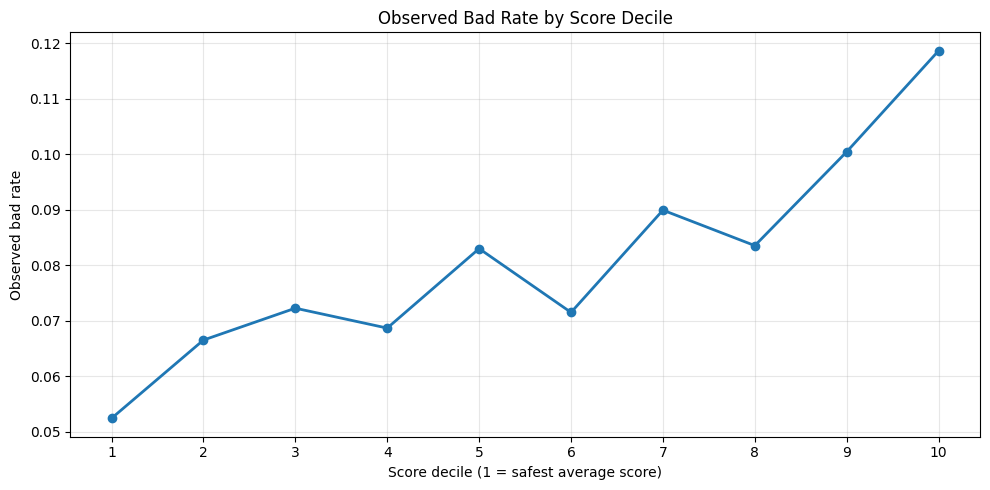

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(decile_table.index + 1, decile_table["bad_rate"], marker="o", linewidth=2)
plt.xticks(decile_table.index + 1)
plt.xlabel("Score decile (1 = safest average score)")
plt.ylabel("Observed bad rate")
plt.title("Observed Bad Rate by Score Decile")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Score-band performance

This table turns the scorecard into something closer to a policy tool.

The goal is not to pretend that score bands are final production cut-offs.  
The goal is to show how model outputs can support:
- approval
- manual review
- decline / senior credit review

In [7]:
band_summary = (
    test_scored.groupby("score_band", observed=False)
    .agg(
        observations=(TARGET, "size"),
        defaults=(TARGET, "sum"),
        bad_rate=(TARGET, "mean"),
        avg_score=("score", "mean"),
        avg_pd=("pd_pred", "mean"),
    )
    .reset_index()
    .sort_values("score_band", ascending=False)
)

band_summary

,score_band,observations,defaults,bad_rate,avg_score,avg_pd
4,E,52622,4842,0.092015,443.232901,0.088830
3,D,12833,895,0.069742,558.611190,0.072246
2,C,11696,844,0.072161,599.433015,0.076651
1,B,7611,481,0.063198,638.914946,0.066005
0,A,7492,386,0.051522,696.963764,0.056270


## 5. Calibration check

Discrimination tells us whether the scorecard ranks risk well.  
Calibration tells us whether predicted PD is reasonably aligned with realised default rates.

For a portfolio notebook, a simple grouped calibration view is enough.

In [8]:
calibration_table = (
    test_scored.assign(pd_bucket=pd.qcut(test_scored["pd_pred"], q=10, duplicates="drop"))
    .groupby("pd_bucket", observed=False)
    .agg(
        observations=(TARGET, "size"),
        avg_predicted_pd=("pd_pred", "mean"),
        observed_bad_rate=(TARGET, "mean"),
    )
    .reset_index()
)

calibration_table

,pd_bucket,observations,avg_predicted_pd,observed_bad_rate
0,"(0.0017399999999999998, 0.0219]",9226,0.015520,0.017017
1,"(0.0219, 0.0321]",9225,0.026998,0.026125
2,"(0.0321, 0.0421]",9225,0.037111,0.035230
3,"(0.0421, 0.0531]",9226,0.047457,0.050618
4,"(0.0531, 0.0657]",9225,0.059163,0.058428
5,"(0.0657, 0.0808]",9225,0.073070,0.073388
6,"(0.0808, 0.0997]",9226,0.089956,0.092023
7,"(0.0997, 0.124]",9225,0.111374,0.108184
8,"(0.124, 0.161]",9225,0.140843,0.137127
9,"(0.161, 0.423]",9226,0.203025,0.209191


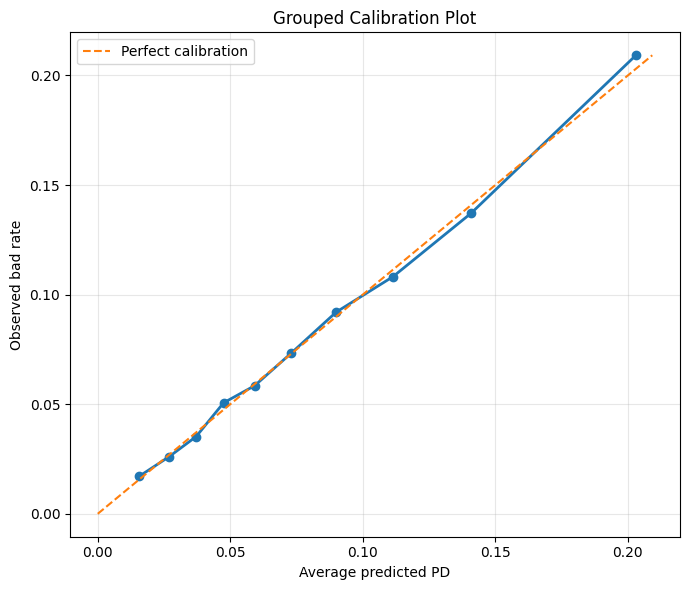

In [9]:
plt.figure(figsize=(7, 6))
plt.plot(calibration_table["avg_predicted_pd"], calibration_table["observed_bad_rate"], marker="o", linewidth=2)
max_axis = max(calibration_table["avg_predicted_pd"].max(), calibration_table["observed_bad_rate"].max())
plt.plot([0, max_axis], [0, max_axis], linestyle="--", linewidth=1.5, label="Perfect calibration")
plt.xlabel("Average predicted PD")
plt.ylabel("Observed bad rate")
plt.title("Grouped Calibration Plot")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Variable interpretation

This is the section that helps in interviews.

Instead of just showing coefficients, explain the business story:
- which variables drive risk up
- which variables reduce risk
- why that makes sense in credit terms

In [10]:
top_positive = coef_table.sort_values("coefficient", ascending=False).head(8).copy()
top_negative = coef_table.sort_values("coefficient", ascending=True).head(8).copy()

print("Top positive risk drivers:")
display(top_positive)

print("\nTop negative risk drivers:")
display(top_negative)

Top positive risk drivers:


,feature,coefficient,odds_ratio,direction
0,PREV_IS_REFUSED_MEAN,-0.454908,0.634507,Lower default risk
1,INSTAL_IS_LATE_MEAN,-0.479181,0.619290,Lower default risk
2,EMPLOYMENT_YEARS,-0.509585,0.600745,Lower default risk
3,AGE,-0.515050,0.597471,Lower default risk
4,LTV_PROXY,-0.576510,0.561856,Lower default risk
5,ANNUITY_TO_CREDIT,-0.579667,0.560085,Lower default risk
6,POS_COUNT,-0.628502,0.533390,Lower default risk
7,PREV_CNT_PAYMENT_MAX,-0.636563,0.529108,Lower default risk



Top negative risk drivers:


,feature,coefficient,odds_ratio,direction
11,EXT_SOURCE_3,-1.146079,0.317881,Lower default risk
10,BUREAU_IS_ACTIVE_SUM,-0.954329,0.385070,Lower default risk
9,BUREAU_DAYS_CREDIT_MEAN,-0.913574,0.401088,Lower default risk
8,EXT_SOURCE_2,-0.799571,0.449522,Lower default risk
7,PREV_CNT_PAYMENT_MAX,-0.636563,0.529108,Lower default risk
6,POS_COUNT,-0.628502,0.533390,Lower default risk
5,ANNUITY_TO_CREDIT,-0.579667,0.560085,Lower default risk
4,LTV_PROXY,-0.576510,0.561856,Lower default risk


### Suggested business interpretation

Use this kind of language in GitHub or interviews:

- **Repayment burden variables** increase risk because borrowers with stretched cash flow have less room to absorb shocks.
- **Leverage variables** increase risk because higher debt relative to collateral or income usually weakens resilience.
- **Behavioural arrears variables** increase risk because recent payment friction often appears before formal default.
- **External credit score variables** usually reduce risk because they capture broader repayment quality outside the application file.
- **Stability variables** such as age or employment length often indicate a more established borrower profile.

The exact final interpretation should be confirmed using your fitted coefficient table and WOE trend review.

## 7. Simple policy strategy overlay

A model becomes more business-relevant once you show how it could be used in a decision process.

This section creates a simple example:
- **A / B bands** → fast-track approval or standard approval
- **C band** → manual review
- **D / E bands** → decline or senior review

These are portfolio illustration rules, not final production policy.

In [11]:
policy_table = band_summary.copy()

policy_table["suggested_action"] = np.select(
    [
        policy_table["score_band"].isin(["A", "B"]),
        policy_table["score_band"].isin(["C"]),
        policy_table["score_band"].isin(["D", "E"]),
    ],
    [
        "Approve / standard credit path",
        "Manual review / analyst judgement",
        "Decline or escalate to senior credit",
    ],
    default="Review"
)

policy_table

,score_band,observations,defaults,bad_rate,avg_score,avg_pd,suggested_action
4,E,52622,4842,0.092015,443.232901,0.088830,Decline or escalate to senior credit
3,D,12833,895,0.069742,558.611190,0.072246,Decline or escalate to senior credit
2,C,11696,844,0.072161,599.433015,0.076651,Manual review / analyst judgement
1,B,7611,481,0.063198,638.914946,0.066005,Approve / standard credit path
0,A,7492,386,0.051522,696.963764,0.056270,Approve / standard credit path


## 8. Executive summary for GitHub README or interviews

This notebook supports the following story:

> I first built an enhanced exploratory PD model on the Home Credit dataset.  
> Then I translated the predictive model into a governed scorecard workflow using WOE binning, IV review and logistic regression on WOE variables.  
> Finally, I validated the scorecard using AUC, Gini, KS, decile analysis and grouped calibration, and showed how score bands can support approval and review decisions.

That is a much stronger portfolio story than stopping at raw logistic regression.

## 9. Save validation outputs

In [12]:
validation_summary.to_csv(OUTPUT_DIR / "08_validation_summary.csv", index=False)
decile_table.to_csv(OUTPUT_DIR / "09_decile_table.csv", index=False)
band_summary.to_csv(OUTPUT_DIR / "10_score_band_summary.csv", index=False)
calibration_table.to_csv(OUTPUT_DIR / "11_calibration_table.csv", index=False)
policy_table.to_csv(OUTPUT_DIR / "12_policy_table.csv", index=False)

print("Saved validation outputs to:", OUTPUT_DIR.resolve())
sorted([p.name for p in OUTPUT_DIR.iterdir()])

Saved validation outputs to: D:\Jane\Job Search\Github\bank\github project\scorecard pd ead consummer credit\output\scorecard_outputs


['01_iv_summary.csv',
 '02_woe_table.csv',
 '03_scorecard_coefficients.csv',
 '04_scorecard_points.csv',
 '05_train_scored.csv',
 '06_test_scored.csv',
 '07_scorecard_metadata.csv',
 '08_validation_summary.csv',
 '09_decile_table.csv',
 '10_score_band_summary.csv',
 '11_calibration_table.csv',
 '12_policy_table.csv']

## 10. Next improvement ideas

Once this scorecard is working end to end, the most sensible next upgrades are:
1. monotonic manual bin review
2. population stability index by score band
3. reject inference discussion
4. time-based validation split
5. calibration to long-run or through-the-cycle PD
6. score-to-grade mapping with portfolio default benchmarks

Those are stronger next steps than simply chasing a slightly higher AUC.